In [ ]:
import pickle

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from yellowbrick.classifier import ConfusionMatrix

# Árvores de decisão

Comece recuperando os dados preditores, de treino e de teste, a partir do arquivo `cover_type.pkl` salvo na pasta do Drive. Lembre-se de que você deve instanciar as variáveis `X` e `y`, dos splits `train` e `test`,  na mesma ordem que salvou.

In [ ]:
with open('./Variaveis/cover_type.pkl', 'rb') as f:
    (x_treino, y_treino, x_test, y_test) = pickle.load(f)

Use o atributo `shape` para verificar quantas instâncias e quantos atributos têm cada uma dessas variáveis.

In [ ]:
x_treino.shape, y_treino.shape

((7500, 53), (7500,))

In [ ]:
x_test.shape, y_test.shape

((2500, 53), (2500,))

Instancie e treine um classificador da classe `DecisionTreeClassifier`. Use o parâmetro `criterion='gini'` (valor padrão) e `random_state=0`.

In [ ]:
tree_classifier = DecisionTreeClassifier(criterion='gini', random_state=0)
tree_classifier.fit(x_treino, y_treino)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Calcule e exiba as predições feitas no split de teste.

In [ ]:
y_pred = tree_classifier.predict(x_test)

In [ ]:
y_pred

array([4, 4, 1, ..., 6, 4, 5], shape=(2500,))

Calcule a acurácia do classificador.

In [ ]:
accuracy_score(y_pred, y_test)

0.7172

Exiba a matriz de confusão.

0.7172

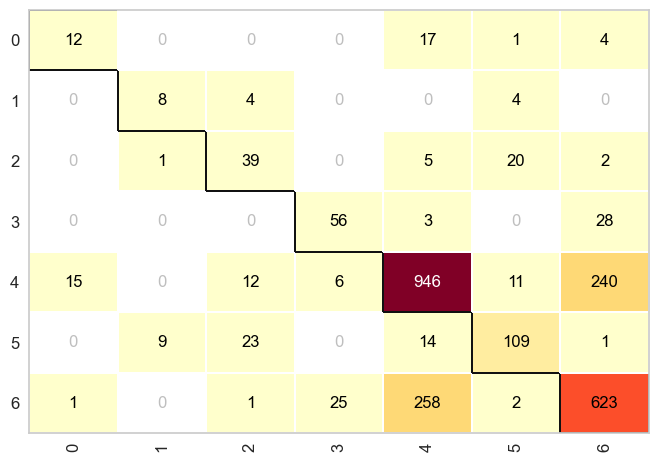

In [ ]:
cm = ConfusionMatrix(tree_classifier)
cm.fit(x_treino, y_treino)
cm.score(x_test, y_test)

Exiba o reporte de classificação.

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.43      0.35      0.39        34
           1       0.44      0.50      0.47        16
           2       0.49      0.58      0.53        67
           3       0.64      0.64      0.64        87
           4       0.76      0.77      0.77      1230
           5       0.74      0.70      0.72       156
           6       0.69      0.68      0.69       910

    accuracy                           0.72      2500
   macro avg       0.60      0.60      0.60      2500
weighted avg       0.72      0.72      0.72      2500



A árvore de decisão já ficou muito melhor que o classificador bayesiano.

Agora repita o exercício utilizando a classe `RandomForestClassifier`. Nós não vamos informar `n_estimators` (o algoritmo vai utilizar o valor padrão de 100), nem `criterion` (o padrão é Gini). Para garantir reprodutibilidade, informe `random_state=0`.

In [ ]:
random_tree_classifier = RandomForestClassifier(n_estimators=100, random_state=0)
random_tree_classifier.fit(x_treino, y_treino)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
previsoes = random_tree_classifier.predict(x_test)
previsoes

array([4, 4, 5, ..., 6, 6, 2], shape=(2500,))

In [ ]:
accuracy_score(previsoes, y_test)

0.8064

0.8064

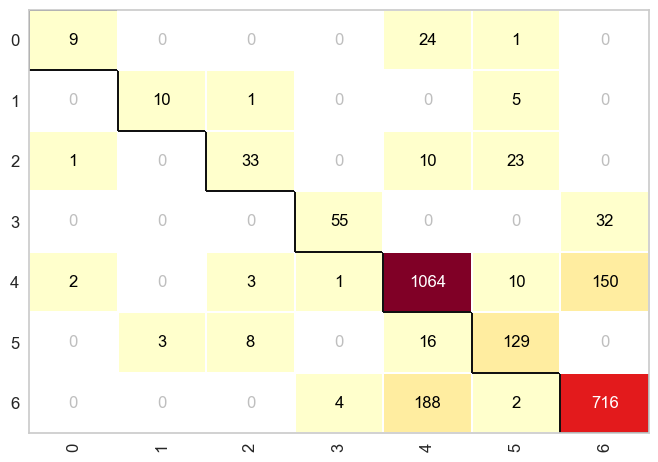

In [ ]:
cm = ConfusionMatrix(random_tree_classifier)
cm.fit(x_treino, y_treino)
cm.score(x_test, y_test)

In [ ]:
print(classification_report(y_test,previsoes))

              precision    recall  f1-score   support

           0       0.75      0.26      0.39        34
           1       0.77      0.62      0.69        16
           2       0.73      0.49      0.59        67
           3       0.92      0.63      0.75        87
           4       0.82      0.87      0.84      1230
           5       0.76      0.83      0.79       156
           6       0.80      0.79      0.79       910

    accuracy                           0.81      2500
   macro avg       0.79      0.64      0.69      2500
weighted avg       0.81      0.81      0.80      2500



---

**EXTRA**

[Consulte a documentação](https://scikit-learn.org/stable/api/sklearn.ensemble.html) e escolha um outro classificador do tipo *ensemble* para treinar. Observação: pode ser que nem todos os classificadores funcionem, pois eles podem ter restrições quanto ao formato dos dados apresentados.

Abaixo como exemplo está o `GradientBoostingClassifier`.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
grad_boost = GradientBoostingClassifier(random_state=0)
grad_boost.fit(x_treino, y_treino)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [ ]:
graf_pred = grad_boost.predict(x_test)
graf_pred

array([4, 4, 1, ..., 6, 6, 5], shape=(2500,))

In [ ]:
accuracy_score(graf_pred, y_test)

0.7524

0.7524

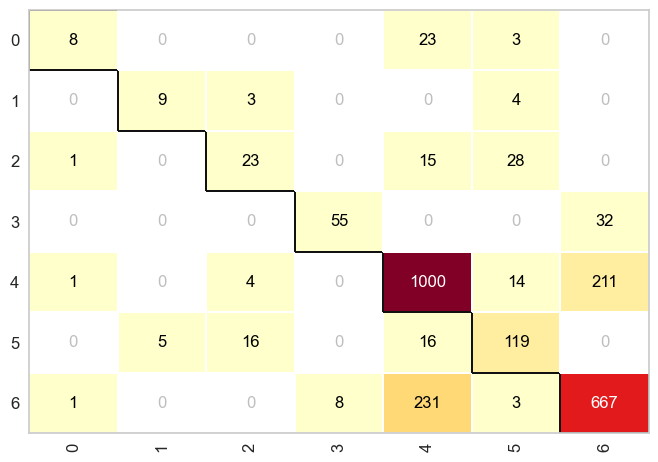

In [ ]:
cm = ConfusionMatrix(grad_boost)
cm.fit(x_treino, y_treino)
cm.score(x_test,y_test)

In [ ]:
print(classification_report(y_test, graf_pred))

              precision    recall  f1-score   support

           0       0.73      0.24      0.36        34
           1       0.64      0.56      0.60        16
           2       0.50      0.34      0.41        67
           3       0.87      0.63      0.73        87
           4       0.78      0.81      0.80      1230
           5       0.70      0.76      0.73       156
           6       0.73      0.73      0.73       910

    accuracy                           0.75      2500
   macro avg       0.71      0.58      0.62      2500
weighted avg       0.75      0.75      0.75      2500

